Convert Categorical Data to Numerical


### Load the Dataset





In [16]:
import pandas as pd  

# Load dataset
df = pd.read_csv("C:/Users/Farooq/OneDrive/Documents/Final year project/Chosen Research paper/ProjectFile/Data/mock_data_test.csv")

# Display first few rows
df.head()

# # Display last few rows
# df.tail()


,student_id,student_name,age,email,gpa,Difficulty_level,recommended_courses,College_Name,Course_Subject
0,1,Gillie Axtens,20,gaxtens0@slate.com,4.2,Intermediate,Front end Development,CIT,Data Science
1,2,Adrea Witherby,19,awitherby1@businessweek.com,7.7,Intermediate,Front end Development,Meenakshi,Data Science
2,3,Arleen Bellhanger,19,abellhanger2@accuweather.com,10.0,Intermediate,NaN,SRM,Cloud Computing
3,4,Annetta Stanyland,20,astanyland3@shop-pro.jp,8.5,Beginner,SQL,SIET,Data Science
4,5,Ferrel Atack,19,fatack4@newyorker.com,4.5,Beginner,Big Data Analytics,Crescent,Data Science


### Handle Missing Values

In [17]:
# Check missing values
print(df.isnull().sum())

# Fill missing GPAs with the mean
df['gpa'].fillna(df['gpa'].mean(), inplace=True)

# Drop rows where essential data is missing
df.dropna(subset=['recommended_courses'], inplace=True)


student_id               0
student_name             0
age                      0
email                    0
gpa                      0
Difficulty_level         0
recommended_courses    126
College_Name             0
Course_Subject           0
dtype: int64


### Handle Duplicates

In [18]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)
df.head()


,student_id,student_name,age,email,gpa,Difficulty_level,recommended_courses,College_Name,Course_Subject
0,1,Gillie Axtens,20,gaxtens0@slate.com,4.2,Intermediate,Front end Development,CIT,Data Science
1,2,Adrea Witherby,19,awitherby1@businessweek.com,7.7,Intermediate,Front end Development,Meenakshi,Data Science
3,4,Annetta Stanyland,20,astanyland3@shop-pro.jp,8.5,Beginner,SQL,SIET,Data Science
4,5,Ferrel Atack,19,fatack4@newyorker.com,4.5,Beginner,Big Data Analytics,Crescent,Data Science
5,6,Othella Leece,19,oleece5@gravatar.com,6.3,Beginner,SQL,SIET,Data Science


## Convert Categorical Data to Numerical
### Goal: Convert non-numeric data for ML models.

1. Label Encoding for categorical values (if ordinal).
2. One-Hot Encoding for non-ordinal categorical values.

In [19]:
from sklearn.preprocessing import LabelEncoder

# Encode Difficulty Level (e.g., Easy → 0, Medium → 1, Hard → 2)
encoder = LabelEncoder()
df['Difficulty_level'] = encoder.fit_transform(df['Difficulty_level'])

# One-Hot Encoding for College Names
df = pd.get_dummies(df, columns=['College_Name'])
df.head()


,student_id,student_name,age,email,gpa,Difficulty_level,recommended_courses,Course_Subject,College_Name_CIT,College_Name_Crescent,College_Name_Meenakshi,College_Name_Rajalakshmi,College_Name_SIET,College_Name_SRM
0,1,Gillie Axtens,20,gaxtens0@slate.com,4.2,2,Front end Development,Data Science,True,False,False,False,False,False
1,2,Adrea Witherby,19,awitherby1@businessweek.com,7.7,2,Front end Development,Data Science,False,False,True,False,False,False
3,4,Annetta Stanyland,20,astanyland3@shop-pro.jp,8.5,1,SQL,Data Science,False,False,False,False,True,False
4,5,Ferrel Atack,19,fatack4@newyorker.com,4.5,1,Big Data Analytics,Data Science,False,True,False,False,False,False
5,6,Othella Leece,19,oleece5@gravatar.com,6.3,1,SQL,Data Science,False,False,False,False,True,False


## Normalize Numerical Features
### Goal: Scale numerical values for better model performance.

1. Use MinMaxScaler (for values between 0-1) or StandardScaler (for normally distributed data).

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['gpa', 'age']] = scaler.fit_transform(df[['gpa', 'age']])


In [21]:
import pandas as pd

# Assuming df is your DataFrame containing the data

# Count the number of occurrences of each course
course_counts = df['recommended_courses'].value_counts()

# Get the top 5 most popular courses
top_5_courses = course_counts.head(5)

# Display the top 5 popular courses and their count
print(top_5_courses)


recommended_courses
Big Data Analytics       138
AWS                      136
SQL                      130
Front end Development    126
Machine Learning         126
Name: count, dtype: int64


In [22]:
# Get a student's preferences (example: student_id = 102)
student_id = 102

# Filter the dataset to get the student's previously recommended courses
student_data = df[df['student_id'] == student_id]

# Get the difficulty level for this student (assuming difficulty levels are encoded)
student_difficulty = student_data['Difficulty_level'].mode()[0]  # Most common difficulty level

# Filter courses that match the same difficulty level
recommended_courses = df[df['Difficulty_level'] == student_difficulty]['recommended_courses'].value_counts()

# Get the top 5 courses based on the same difficulty level
top_courses = recommended_courses.head(5)

print(f"Top 5 Recommended Courses for Student ID {student_id} based on Difficulty Level:")
print(top_courses)

Top 5 Recommended Courses for Student ID 102 based on Difficulty Level:
recommended_courses
Big Data Analytics       44
SQL                      37
Front end Development    36
Backend Development      34
Machine Learning         34
Name: count, dtype: int64


Top 5 Recommended Courses for Student ID 102:
recommended_courses
Big Data Analytics       44
SQL                      37
Front end Development    36
Backend Development      34
Machine Learning         34
Name: count, dtype: int64


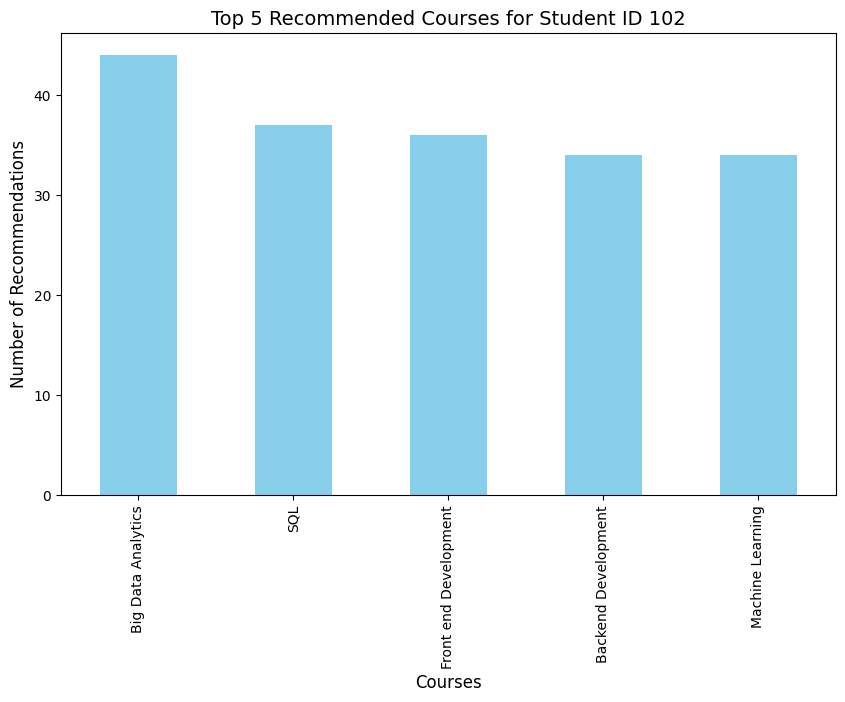

In [24]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# Function to recommend courses based on student's difficulty level
def recommend_courses(student_id, df):
    student_data = df[df['student_id'] == student_id]
    student_difficulty = student_data['Difficulty_level'].mode()[0]  # Most common difficulty level
    recommended_courses = df[df['Difficulty_level'] == student_difficulty]['recommended_courses'].value_counts()
    return recommended_courses.head(5)

### Example usage for a specific student
student_id = 102
top_courses = recommend_courses(student_id, df)

# Display the top 5 recommended courses
print(f"Top 5 Recommended Courses for Student ID {student_id}:")
print(top_courses)

# Graphical representation (Bar Chart)
plt.figure(figsize=(10, 6))
top_courses.plot(kind='bar', color='skyblue')

# Adding titles and labels
plt.title(f"Top 5 Recommended Courses for Student ID {student_id}", fontsize=14)
plt.xlabel('Courses', fontsize=12)
plt.ylabel('Number of Recommendations', fontsize=12)

# Display the plot
plt.show()


## Feature Engineering (Optional but Recommended)
### Goal: Create new meaningful features.

1. Engagement Score → Based on time spent on different topics.
2. Course Popularity Score → Count how often a course is recommended.

In [47]:
# Example: Add a Course Popularity Score
df['course_popularity'] = df.groupby('recommended_courses')['recommended_courses'].transform('count')


### Save the Cleaned Dataset

In [48]:
df.to_csv("C:/Users/Farooq/OneDrive/Documents/Final year project/Chosen Research paper/ProjectFile/Data/mock_data_test.csv", index=False)

1. Identify Top-Tier Courses Based on Interests
2. Here’s how we can filter the best courses:

In [49]:
# def recommend_top_courses(student_id, df, top_n=5):
#     """ Recommend top-tier courses based on student interest. """
    
#     # Get the student's details
#     student = df[df['student_id'] == student_id]
    
#     if student.empty:
#         return "Student ID not found"
    
#     # Extract the student's Course_Subject interest & Difficulty Level
#     interest = student['Course_Subject'].values[0]
#     difficulty = student['Difficulty_level'].values[0]
    
#     # Filter top courses matching the same subject & difficulty
#     recommended_courses = df[
#         (df['Course_Subject'] == interest) & 
#         (df['Difficulty_level'] <= difficulty)  # Consider slightly easier courses too
#     ]
    
#     # Sort by highest GPA students taking the course (proxy for top-tier)
#     recommended_courses = recommended_courses.sort_values(by='gpa', ascending=False)
    
#     return recommended_courses[['recommended_courses', 'College_Name']].head(top_n)

# # Example Usage
# student_id = 102  # Change this to a real student ID
# top_courses = recommend_top_courses(student_id, df)
# print(top_courses)



# def recommend_top_courses(student_id, df, top_n=5):
#     """ Recommend top-tier courses based on student interest. """
    
#     # Get the student's details
#     student = df[df['student_id'] == student_id]
    
#     if student.empty:
#         return "Student ID not found"
    
#     # Extract the student's Course_Subject interest & Difficulty Level
#     interest = student['Course_Subject'].values[0]
#     difficulty = student['Difficulty_level'].values[0]
    
#     # Filter top courses matching the same subject & difficulty
#     recommended_courses = df[
#         (df['Course_Subject'] == interest) & 
#         (df['Difficulty_level'] <= difficulty)  
#     ]
    
#     # Check if results exist before proceeding
#     if recommended_courses.empty:
#         return "No matching courses found for this student."

#     # Sort by highest GPA students taking the course
#     recommended_courses = recommended_courses.sort_values(by='gpa', ascending=False)

#     # Ensure column exists before selection
#     available_columns = set(recommended_courses.columns)
#     required_columns = {'recommended_courses', 'College_Name'}
    
#     if not required_columns.issubset(available_columns):
#         return "Missing required columns in filtered data."

#     return recommended_courses[['recommended_courses', 'College_Name']].head(top_n)
